In [71]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from pyod.utils.data import evaluate_print
from sklearn.model_selection import train_test_split
from datetime import datetime
import numpy as np
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.utils.data import evaluate_print

%matplotlib inline

In [17]:
cpu_data = pd.read_csv('../../Potomac/AIT 620/LabWorks/PythonProject/datafiles/cpu4.csv')

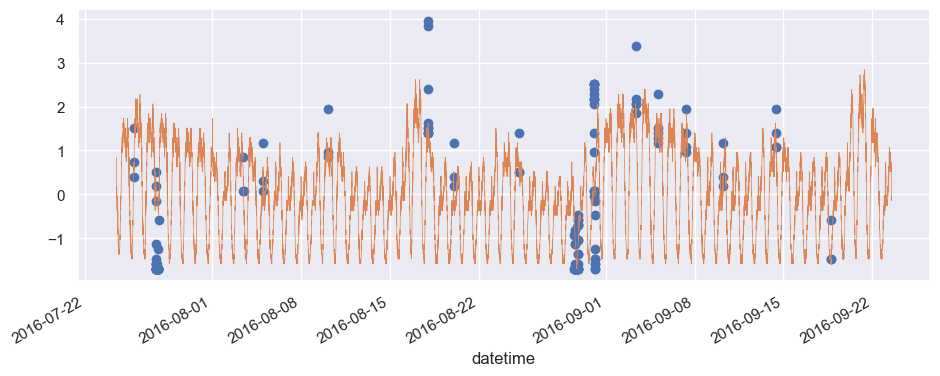

In [18]:
cpu_data['datetime'] = cpu_data.timestamp.astype(int).apply(datetime.fromtimestamp)
sns.set(rc={'figure.figsize':(11, 4)})

time_data = cpu_data.set_index('datetime')
time_data.loc[time_data['label'] == 1.0, 'value'].plot(linewidth=0.5, marker='o', linestyle='')
time_data.loc[time_data['label'] == 0.0, 'value'].plot(linewidth=0.5)

plt.show()

In [5]:
cpu_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  17568 non-null  int64         
 1   value      17568 non-null  float64       
 2   label      17568 non-null  int64         
 3   datetime   17568 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 549.1 KB


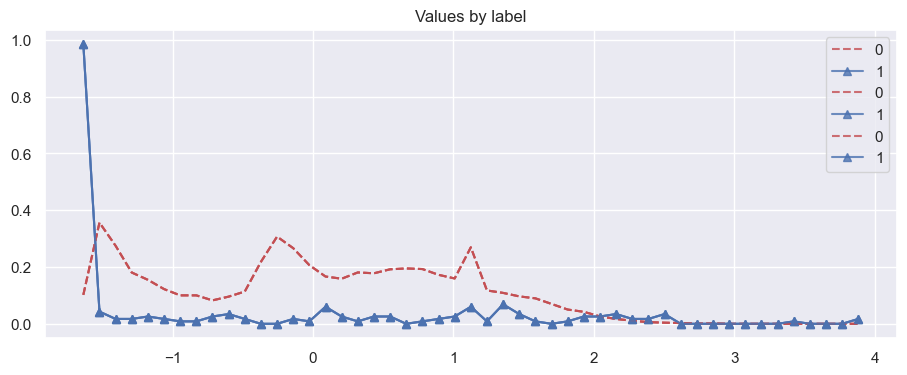

In [21]:
markers = ['r--', 'b-^']
def hist2d(X, by_col, n_bins=10, title=None):
    bins = np.linspace(X.min(), X.max(), n_bins)
    vals = np.unique(by_col)

    for marker, val in zip(markers, vals):
        n, edges = np.histogram(X[by_col == val], bins=bins)
        n = n / np.linalg.norm(n)

        bin_centers = 0.5 * (edges[1:] + edges[:-1])
        plt.plot(bin_centers, n, marker, alpha=0.8, label=val)

    plt.legend(loc='upper right')

    if title is not None:
        plt.title(title)

    plt.show()

hist2d(cpu_data.value, cpu_data.label, n_bins=50, title='Values by label')

In [22]:
len(cpu_data)

17568

In [27]:
cpu_data.timestamp.hist()

<Axes: >

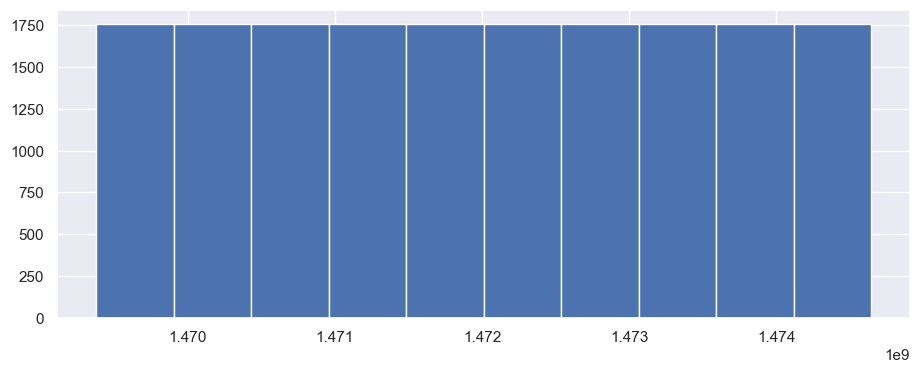

In [28]:
plt.show()

In [30]:
cpu_data.value.hist(bins=50)

<Axes: >

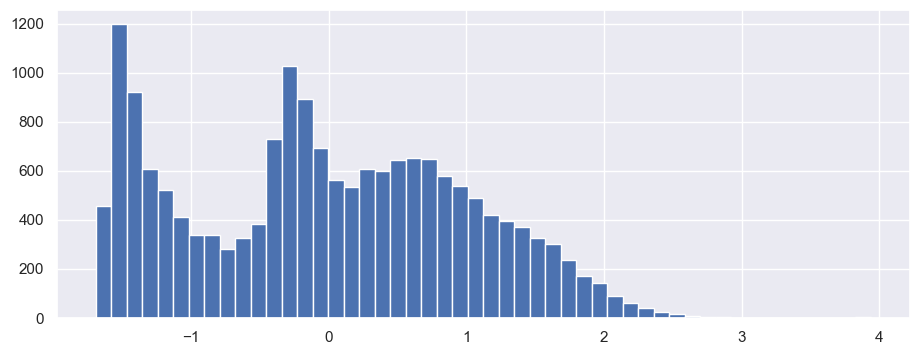

In [31]:
plt.show()

In [32]:
markers = ['r--', 'b-^']

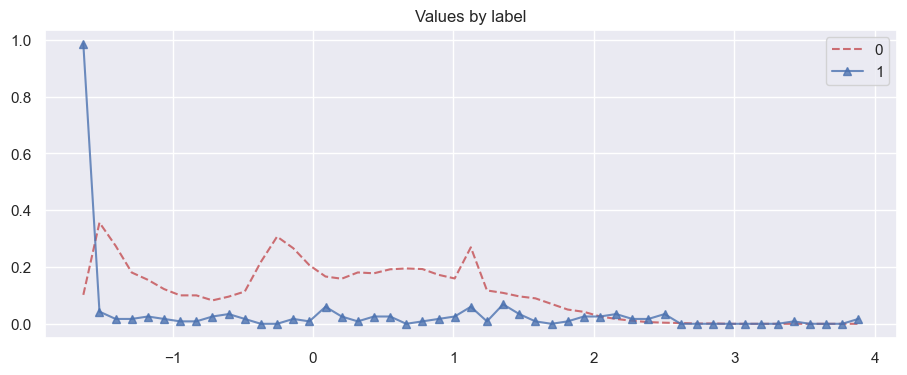

In [33]:
def hist2d(X, by_col, n_bins=10, title=None):
    '''plot two histograms against each other.

    I am using line plots here. Alternatively,
    we could be using hist() with opacity.
    '''
    bins = np.linspace(X.min(), X.max(), n_bins)

    vals = np.unique(by_col)
    for marker, val in zip(markers, vals):
        n, edges = np.histogram(X[by_col == val], bins=bins)
        n = n / np.linalg.norm(n)
        bin_centers = 0.5 * (edges[1:] + edges[:-1])
        plt.plot(bin_centers, n, marker, alpha=0.8, label=val)

    plt.legend(loc='upper right')
    if title is not None:
        plt.title(title)
    plt.show()

hist2d(cpu_data.value, cpu_data.label, n_bins=50, title='Values by label')

In [34]:
cpu_data.label.hist()

<Axes: >

In [35]:
X_train, X_test, y_train, y_test = train_test_split(cpu_data[['value']].values, cpu_data.label.values)

In [37]:

clf_name = 'KNN'
clf = KNN()
clf.fit(X_train)

# get the prediction labels and outlier scores of the training data
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
y_train_scores = clf.decision_scores_  # raw outlier scores

# get the prediction on the test data
y_test_pred = clf.predict(X_test)  # outlier labels (0 or 1)
y_test_scores = clf.decision_function(X_test)  # outlier scores


On Training Data:
KNN ROC:0.506, precision @ rank n:0.2857

On Test Data:
KNN ROC:0.5102, precision @ rank n:0.3333


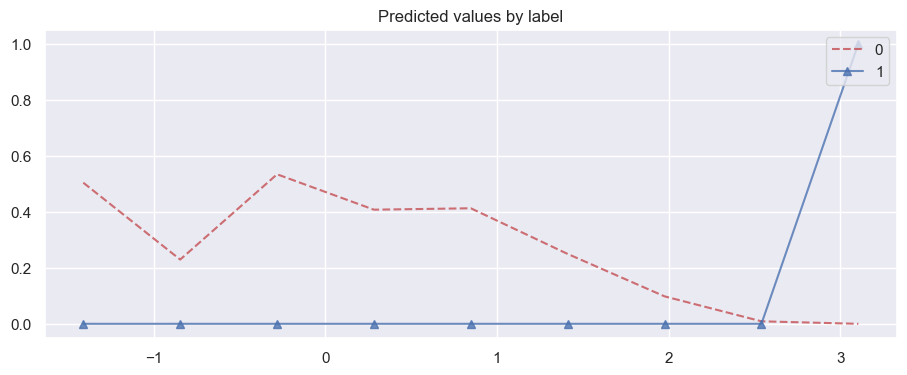

In [42]:
from pyod.utils.data import evaluate_print
# evaluate and print the results
print("\nOn Training Data:")
evaluate_print(clf_name, y_train, y_train_scores)
print("\nOn Test Data:")
evaluate_print(clf_name, y_test, y_test_scores)

hist2d(X_test, y_test_pred, title='Predicted values by label')

In [39]:
X_train[y_train==0.0].shape

X_train.shape

y_train.sum()

np.int64(161)

In [56]:
def test_outlier_detector(X_train, y_train,
                          X_test, y_test, only_neg=True,
                          basemethod=KNN()):
  clf = basemethod
  if only_neg:
    clf.fit(X_train[y_train==0.0], np.zeros(shape=((y_train==0.0).sum(), 1)))
  else:
    clf.fit(X_train, y_train)  # most algorithms ignore y

  y_train_pred = clf.predict(X_train)  # labels_
  y_train_scores = clf.decision_scores_

  y_test_pred = clf.predict(X_test)
  y_test_scores = clf.decision_function(X_test)

  print("\nOn Test Data:")
  evaluate_print(type(clf).__name__, y_test, y_test_scores)
  hist2d(X_test, y_test_pred, title='Predicted values by label')

  # test_outlier_detector(X_train, y_train, X_test, y_test, only_neg=False,
  #                       basemethod=KNN(n_neighbors=3, metric='hamming', method='mean', contamination=0.01))

In [72]:
def test_outlier_detector_if(X_train, y_train,
                          X_test, y_test, only_neg=True,
                          basemethod=IForest()):
  ccf = basemethod
  if only_neg:
    ccf.fit(X_train[y_train==0.0], np.zeros(shape=((y_train==0.0).sum(), 1)))
  else:
    ccf.fit(X_train, y_train)  # most algorithms ignore y

  y_train_pred = ccf.predict(X_train)  # labels_
  y_train_scores =ccf.decision_scores_

  y_test_pred = ccf.predict(X_test)
  y_test_scores = ccf.decision_function(X_test)

  print("\nOn Test Data:")
  evaluate_print(type(clf).__name__, y_test, y_test_scores)
  hist2d(X_test, y_test_pred, title='Predicted values by label')

C:\Users\yathi\anaconda3\Lib\site-packages\pyod\models\base.py:555: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(



On Test Data:
IForest ROC:0.8139, precision @ rank n:0.5789


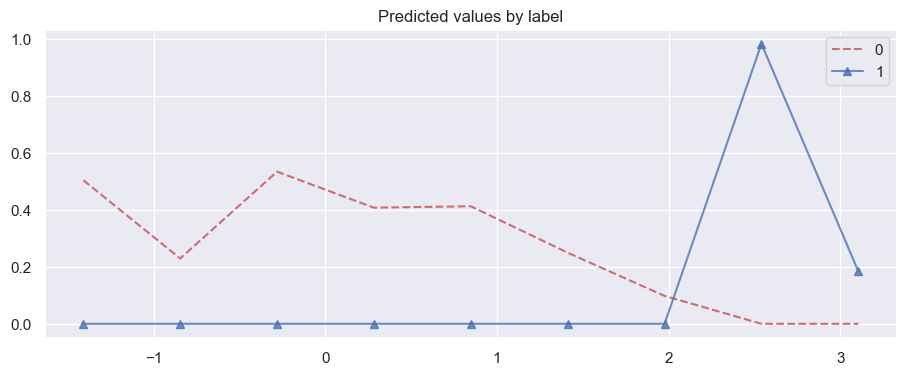

In [75]:
test_outlier_detector(X_train, y_train, X_test, y_test, only_neg=False,
                        basemethod=IForest(contamination=0.01))

C:\Users\yathi\anaconda3\Lib\site-packages\pyod\models\base.py:555: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(



On Test Data:
KNN ROC:0.8219, precision @ rank n:0.1143


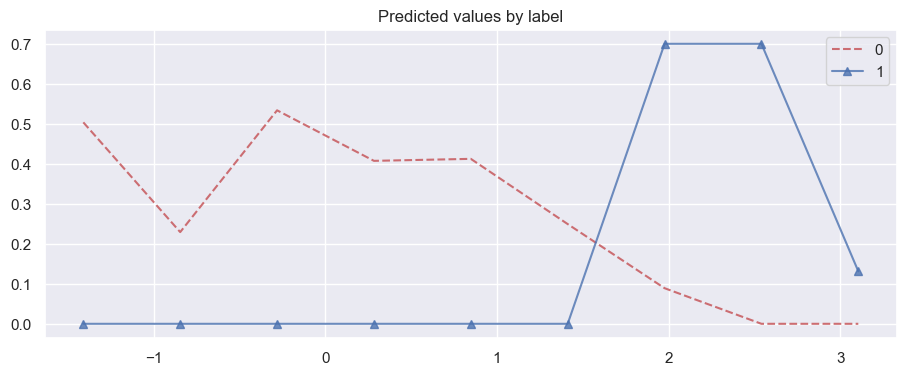

In [76]:
test_outlier_detector_if(X_train, y_train, X_test, y_test, only_neg=False,
                        basemethod=IForest(contamination=0.01))

C:\Users\yathi\anaconda3\Lib\site-packages\pyod\models\base.py:555: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.15it/s]



On Test Data:
AutoEncoder ROC:0.7984, precision @ rank n:0.5789


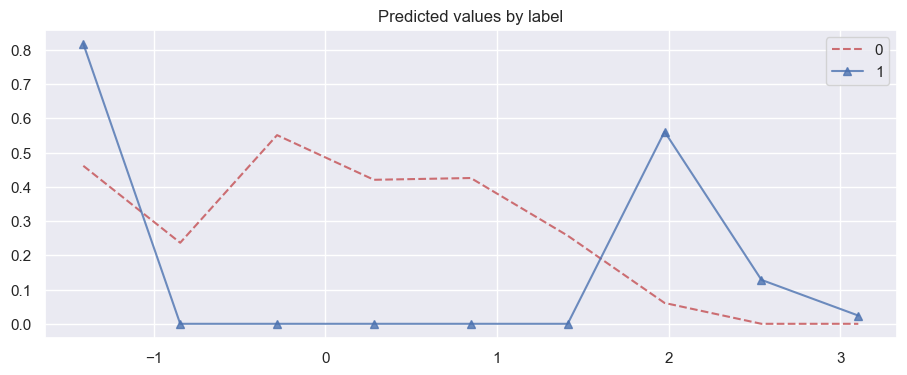

In [64]:
from pyod.models.auto_encoder import AutoEncoder

test_outlier_detector(
    X_train, y_train,
    X_test, y_test,
    only_neg=False,
    basemethod=AutoEncoder(hidden_neuron_list=[1], ep)
)

